# Preprocessing RSNA — MLO, grayscale 512×512, 1 immagine per paziente

Questo notebook prepara il dataset per il progetto:

- legge `dataset/train.csv`;
- usa solo immagini `MLO`;
- considera `cancer` come label;
- seleziona **un solo campione per paziente**;
- se un paziente è positivo, usa solo una sua immagine positiva e **non usa le sue immagini negative**;
- salva immagini preprocessate in `processed_rsna_512_gray`;
- mantiene il formato master in **grayscale 512×512**;
- crea CSV `train.csv`, `val.csv`, `test.csv`, `all_processed.csv`.

La conversione a RGB per Stable Diffusion/MobileNet verrà fatta successivamente, nel dataloader, senza duplicare i file su disco.

In [51]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [33]:
# configurazione iniziale

BASE_DIR = Path.cwd()

DATASET_DIR = BASE_DIR / "dataset"
CSV_PATH = DATASET_DIR / "train.csv"

OUTPUT_DIR = BASE_DIR / "processed_rsna_512_gray"

IMG_SIZE = 512
RANDOM_STATE = 42

VAL_SIZE = 0.15
TEST_SIZE = 0.15

VIEW_FILTER = "MLO"
IMAGE_EXTENSIONS = [".png", ".PNG"]

# Se True, cancella la cartella processed_rsna_512_gray prima di ricrearla.
RESET_OUTPUT_DIR = True

print("BASE_DIR:", BASE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("CSV_PATH:", CSV_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

# assert fa un controllo di sicurezza nel codice, se condizione è vera va avanti, altrimenti stampa messaggio di errore
# assert condizione, "messaggio di errore"
assert DATASET_DIR.exists(), f"Cartella dataset non trovata: {DATASET_DIR}"
assert CSV_PATH.exists(), f"CSV non trovato: {CSV_PATH}"

BASE_DIR: D:\Progetto Deep
DATASET_DIR: D:\Progetto Deep\dataset
CSV_PATH: D:\Progetto Deep\dataset\train.csv
OUTPUT_DIR: D:\Progetto Deep\processed_rsna_512_gray


## 1. Caricamento CSV e controlli iniziali

In [34]:
df_all = pd.read_csv(CSV_PATH)

print("Shape CSV originale:", df_all.shape)
display(df_all.head())
print(df_all.columns.tolist())

Shape CSV originale: (54706, 14)


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']


In [35]:
required_cols = ["patient_id", "image_id", "laterality", "view", "cancer"]

missing_cols = [col for col in required_cols if col not in df_all.columns]
if missing_cols:
    raise ValueError(f"Errore, mancano alcune colonne obbligatorie: {missing_cols}")

df_all = df_all.copy()

df_all["patient_id"] = df_all["patient_id"].astype(str)
df_all["image_id"] = df_all["image_id"].astype(str)
df_all["view"] = df_all["view"].astype(str)
df_all["laterality"] = df_all["laterality"].astype(str)
df_all["cancer"] = df_all["cancer"].astype(int)

print("Distribuzione originale:")
print(df_all["cancer"].value_counts())

print("\nNumero pazienti originali:", df_all["patient_id"].nunique())
print("Pazienti positivi originali:", int(df_all.groupby("patient_id")["cancer"].max().sum()))

print("\nDistribuzione view:")
print(df_all["view"].value_counts())

Distribuzione originale:
cancer
0    53548
1     1158
Name: count, dtype: int64

Numero pazienti originali: 11913
Pazienti positivi originali: 486

Distribuzione view:
view
MLO    27903
CC     26765
AT        19
LM        10
ML         8
LMO        1
Name: count, dtype: int64


## 2. Indicizzazione immagini PNG

Le immagini sono sparse dentro `dataset/`, quindi qui creiamo una mappa `image_id → path`.

Il codice supporta nomi tipo:

- `image_id.png`
- `patient_id_image_id.png`
- altri nomi che contengono `image_id` come token separato da `_` o `-`.

In [36]:
# indicizzazine png

png_files = []
for ext in IMAGE_EXTENSIONS:
    png_files.extend(DATASET_DIR.rglob(f"*{ext}"))

# Rimuove duplicati mantenendo ordine
png_files = list(dict.fromkeys(png_files))

print("PNG trovate:", len(png_files))
if len(png_files) == 0:
    raise FileNotFoundError(f"Nessuna immagine PNG trovata dentro {DATASET_DIR}")

# Mappa per stem esatto (nome del file senza estensione)
stem_map = {}
duplicate_stems = set()

for p in png_files:
    stem = p.stem
    if stem in stem_map:
        duplicate_stems.add(stem)
    else:
        stem_map[stem] = p

# Mappa per token contenuti nel nome.
# Se un token compare in più file, lo marchiamo come ambiguo e non lo usiamo.
token_map = {}
ambiguous_tokens = set()

for p in png_files:
    stem = p.stem
    tokens = stem.replace("-", "_").split("_") # splittiamo perchè potremmo avere image_id _ altro
    # nel csv potrebbero essere indicate anche solo con l'image_id
    tokens.append(stem)

    for token in tokens: # scorre ogni pezzo del nome file
        if token in token_map and token_map[token] != p: 
        # controllo se un token fosse già stato associato a un altro file
            ambiguous_tokens.add(token)
        else:
            token_map[token] = p

for token in ambiguous_tokens:
    token_map.pop(token, None) # rimozione token "ambigui", cioè che compaiono in più file diversi

print("Stem unici indicizzati:", len(stem_map))
print("Token unici indicizzati:", len(token_map))
print("Stem duplicati ignorati:", len(duplicate_stems))
print("Token ambigui ignorati:", len(ambiguous_tokens))

PNG trovate: 54706
Stem unici indicizzati: 54706
Token unici indicizzati: 109412
Stem duplicati ignorati: 0
Token ambigui ignorati: 11913


In [37]:
def find_image_path(patient_id, image_id):
    """
    Cerca l'immagine dentro DATASET_DIR.
    Supporta:
    - image_id.png
    - patient_id_image_id.png
    - file con image_id incluso nel nome
    """
    patient_id = str(patient_id)
    image_id = str(image_id)

    # Candidati diretti più probabili
    for ext in IMAGE_EXTENSIONS:
        candidates = [
            DATASET_DIR / f"{image_id}{ext}",
            DATASET_DIR / f"{patient_id}_{image_id}{ext}",
            DATASET_DIR / f"{image_id}_{patient_id}{ext}",
        ]

        for candidate in candidates:
            if candidate.exists():
                return candidate

    # Mappa su nome senza estensione
    exact_keys = [
        image_id,
        f"{patient_id}_{image_id}",
        f"{image_id}_{patient_id}",
    ]

    for key in exact_keys:
        if key in stem_map:
            return stem_map[key]

    # Fallback: image_id come token unico nel nome file
    if image_id in token_map:
        return token_map[image_id]

    return None

## 3. Filtro MLO e selezione corretta dei pazienti

Regola usata:

- paziente positivo = almeno una immagine con `cancer = 1`;
- paziente negativo = tutte le immagini con `cancer = 0`;
- per i pazienti positivi prendiamo solo immagini `MLO` con `cancer = 1`;
- per i pazienti negativi prendiamo immagini `MLO` con `cancer = 0`;
- evitiamo che un paziente positivo contribuisca anche come negativo.

In [38]:
# label dei pazienti

patient_label_df = (
    df_all.groupby("patient_id", as_index=False)["cancer"]
    .max()
    .rename(columns={"cancer": "patient_label"})
)

df = df_all.merge(patient_label_df, on="patient_id", how="left")

# Solo vista MLO
df_mlo = df[df["view"] == VIEW_FILTER].copy().reset_index(drop=True)

print("Immagini MLO:", len(df_mlo))
print("\nDistribuzione cancer nelle MLO:")
print(df_mlo["cancer"].value_counts())

print("\nPazienti nelle MLO:", df_mlo["patient_id"].nunique())
print("Pazienti positivi con almeno una MLO:", int(df_mlo.groupby("patient_id")["patient_label"].max().sum()))

Immagini MLO: 27903

Distribuzione cancer nelle MLO:
cancer
0    27313
1      590
Name: count, dtype: int64

Pazienti nelle MLO: 11913
Pazienti positivi con almeno una MLO: 486


In [39]:
# Positive: paziente positivo + immagine MLO positiva

positive_candidates = df_mlo[
    (df_mlo["patient_label"] == 1) &
    (df_mlo["cancer"] == 1)
].copy().reset_index(drop=True)

# Negative: paziente realmente negativo, escludiamo le immagini negative appartenenti a pazienti positivi.
negative_candidates = df_mlo[
    (df_mlo["patient_label"] == 0) &
    (df_mlo["cancer"] == 0)
].copy().reset_index(drop=True)

print("Candidati positivi MLO:", len(positive_candidates))
print("Pazienti positivi con MLO positiva:", positive_candidates["patient_id"].nunique())

print("\nCandidati negativi MLO:", len(negative_candidates))
print("Pazienti negativi con MLO:", negative_candidates["patient_id"].nunique())

Candidati positivi MLO: 590
Pazienti positivi con MLO positiva: 486

Candidati negativi MLO: 26739
Pazienti negativi con MLO: 11427


## 4. Un solo campione per paziente

Qui evitiamo `groupby.apply`, perché in alcune versioni di pandas può spostare o rimuovere la colonna `patient_id`.  
Usiamo invece una colonna random e `drop_duplicates("patient_id")`, così `patient_id` resta sicuramente una colonna.

In [40]:
def choose_one_per_patient(input_df, random_state=42):
    """
    Seleziona una sola riga per patient_id in modo riproducibile.
    Non usa groupby.apply, quindi evita problemi in cui patient_id diventa indice.
    """
    
    if "patient_id" not in input_df.columns:
        raise ValueError("La colonna patient_id non è presente nel dataframe di input.")

    rng = np.random.default_rng(random_state)

    out = input_df.copy().reset_index(drop=True)
    out["_random_choice"] = rng.random(len(out))

    out = (
        out.sort_values(["patient_id", "_random_choice"])
        .drop_duplicates(subset=["patient_id"], keep="first")
        .drop(columns=["_random_choice"])
        .reset_index(drop=True)
    )

    return out


positive_one = choose_one_per_patient(positive_candidates, random_state=RANDOM_STATE)
negative_one = choose_one_per_patient(negative_candidates, random_state=RANDOM_STATE + 1)

selected_df = pd.concat([positive_one, negative_one], ignore_index=True)
selected_df = selected_df.reset_index(drop=True)

# Label finale per il progetto
selected_df["label"] = selected_df["cancer"].astype(int)

print("Colonne selected_df:")
print(selected_df.columns.tolist())

print("\nDataset selezionato:", selected_df.shape)
print("\nDistribuzione label:")
print(selected_df["label"].value_counts())

print("\nPazienti unici:", selected_df["patient_id"].nunique())

assert "patient_id" in selected_df.columns, "Errore: patient_id non è una colonna."
assert selected_df["patient_id"].nunique() == len(selected_df), "Errore: ci sono più immagini per lo stesso paziente."
assert set(selected_df["label"].unique()).issubset({0, 1}), "Errore: label non binaria."

display(selected_df.head())

Colonne selected_df:
['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case', 'patient_label', 'label']

Dataset selezionato: (11913, 16)

Distribuzione label:
label
0    11427
1      486
Name: count, dtype: int64

Pazienti unici: 11913


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,patient_label,label
0,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False,1,1
1,1,10226,461614796,L,MLO,71.0,1,1,1,0.0,0,C,49,False,1,1
2,1,1025,1803952236,L,MLO,56.0,1,1,0,0.0,0,B,49,False,1,1
3,2,10432,1434858530,L,MLO,65.0,1,1,1,NaN,0,NaN,48,False,1,1
4,1,10589,605115808,L,MLO,74.0,1,1,1,0.0,0,B,170,False,1,1


In [41]:
# Fissiamo un rate di negativi rispetto al numero di positivi

NEGATIVE_TO_POSITIVE_RATIO = 5

positive_df = selected_df[selected_df["label"] == 1].copy()
negative_df = selected_df[selected_df["label"] == 0].copy()

n_pos = len(positive_df)
n_neg_available = len(negative_df)

if n_pos == 0:
    raise ValueError("Non ci sono positivi in selected_df: impossibile fissare il rapporto negativi/positivi.")

if NEGATIVE_TO_POSITIVE_RATIO is None:
    n_neg_target = n_neg_available
else:
    n_neg_target = int(n_pos * NEGATIVE_TO_POSITIVE_RATIO)

    if n_neg_target > n_neg_available:
        print(
            f"Attenzione: richiesti {n_neg_target} negativi, "
            f"ma disponibili solo {n_neg_available}. Verranno usati tutti i negativi disponibili."
        )
        n_neg_target = n_neg_available

negative_sampled_df = negative_df.sample(
    n=n_neg_target,
    random_state=RANDOM_STATE
).copy()

selected_df = pd.concat(
    [positive_df, negative_sampled_df],
    ignore_index=True
)

# Shuffle finale riproducibile
selected_df = selected_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Dataset dopo definizione rapporto negativi/positivi:")
print(selected_df["label"].value_counts())

actual_n_pos = (selected_df["label"] == 1).sum()
actual_n_neg = (selected_df["label"] == 0).sum()

print(f"\nPositivi: {actual_n_pos}")
print(f"Negativi: {actual_n_neg}")
print(f"Rapporto negativi/positivi effettivo: {actual_n_neg / actual_n_pos:.2f}:1")

assert selected_df["patient_id"].nunique() == len(selected_df), "Errore: ci sono più immagini per lo stesso paziente."
assert selected_df["label"].isin([0, 1]).all(), "Errore: label non binaria."

Dataset dopo definizione rapporto negativi/positivi:
label
0    2430
1     486
Name: count, dtype: int64

Positivi: 486
Negativi: 2430
Rapporto negativi/positivi effettivo: 5.00:1


## 5. Associazione dei path immagini

In [42]:
image_paths = []

for _, row in tqdm(selected_df.iterrows(), total=len(selected_df), desc="Ricerca immagini"):
    path = find_image_path(
        patient_id=row["patient_id"],
        image_id=row["image_id"]
    )
    image_paths.append(path)

selected_df["image_path"] = image_paths

missing_df = selected_df[selected_df["image_path"].isna()].copy()

print("Immagini trovate:", selected_df["image_path"].notna().sum())
print("Immagini mancanti:", selected_df["image_path"].isna().sum())

if len(missing_df) > 0:
    print("\nEsempi immagini mancanti:")
    display(missing_df[["patient_id", "image_id", "view", "cancer"]].head(20))

Ricerca immagini: 100%|██████████████████████████████████████████████████████████| 2916/2916 [00:00<00:00, 3596.89it/s]

Immagini trovate: 2916
Immagini mancanti: 0


In [43]:
# Teniamo solo immagini realmente trovate

selected_df = selected_df[selected_df["image_path"].notna()].copy().reset_index(drop=True)
selected_df["image_path"] = selected_df["image_path"].astype(str)

print("Dataset dopo controllo file:", selected_df.shape)
print(selected_df["label"].value_counts())

assert selected_df["patient_id"].nunique() == len(selected_df), "Errore dopo path matching: più immagini per paziente."

Dataset dopo controllo file: (2916, 17)
label
0    2430
1     486
Name: count, dtype: int64


## 6. Split train / val / test

Dato che abbiamo già un solo campione per paziente, lo split può essere fatto sulle righe, ma resta stratificato per `label`.

In [44]:
def stratified_train_val_test_split(df, val_size=0.15, test_size=0.15, random_state=42):
    """
    Split train/val/test stratificato.
    Se la stratificazione non è possibile per pochi campioni, solleva un errore chiaro.
    """
    
    label_counts = df["label"].value_counts()
    if len(label_counts) < 2:
        raise ValueError("Serve almeno una classe positiva e una negativa per fare split stratificato.")

    if (label_counts < 2).any():
        raise ValueError(
            "Almeno una classe ha meno di 2 campioni. "
            "Impossibile fare split stratificato affidabile."
        )

    train_df, temp_df = train_test_split(
        df,
        test_size=val_size + test_size,
        stratify=df["label"],
        random_state=random_state
    )

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df["label"],
        random_state=random_state
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    final_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    return final_df


final_df = stratified_train_val_test_split(
    selected_df,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Distribuzione split/label:")
print(pd.crosstab(final_df["split"], final_df["label"]))

print("\nNumero righe final_df:", len(final_df))
print("Pazienti unici final_df:", final_df["patient_id"].nunique())

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73

Numero righe final_df: 2916
Pazienti unici final_df: 2916


In [45]:
# Controllo anti-leakage
train_patients = set(final_df[final_df["split"] == "train"]["patient_id"])
val_patients = set(final_df[final_df["split"] == "val"]["patient_id"])
test_patients = set(final_df[final_df["split"] == "test"]["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

assert final_df["patient_id"].nunique() == len(final_df)

print("Nessun patient leakage. Un solo campione per paziente.")

Nessun patient leakage. Un solo campione per paziente.


## 7. Funzioni di preprocessing immagine

Output finale:

- PNG
- grayscale
- `mode = L`
- dimensione `512×512`

Il resize mantiene l'aspect ratio e aggiunge padding nero.

In [46]:
def load_as_grayscale_uint8(path):
    """
    Carica un'immagine e la restituisce come PIL grayscale 8-bit.

    Se l'immagine è 16-bit o ha valori molto ampi, applica una normalizzazione robusta
    usando i percentili 0.5 e 99.5 dei pixel non-zero.
    """
    img = Image.open(path)
    arr = np.array(img)

    # Caso RGB/RGBA: conversione PIL standard.
    if arr.ndim == 3:
        return img.convert("L")

    # Caso già uint8 (unsigned integer 8-bit)
    if arr.dtype == np.uint8:
        return Image.fromarray(arr, mode="L")

    # Caso 16-bit o altro: normalizzazione robusta.
    arr = arr.astype(np.float32)

    nonzero = arr[arr > 0]

    if len(nonzero) > 0:
        lo, hi = np.percentile(nonzero, [0.5, 99.5])
    else:
        lo, hi = arr.min(), arr.max()

    if hi <= lo:
        arr_norm = np.zeros_like(arr, dtype=np.uint8)
    else:
        arr = np.clip(arr, lo, hi)
        arr_norm = ((arr - lo) / (hi - lo) * 255.0).astype(np.uint8)

    return Image.fromarray(arr_norm, mode="L")


def resize_with_padding(img, size=512):
    """
    Resize mantenendo aspect ratio + padding nero.
    """
    img = img.copy()

    if img.size == (size, size):
        return img

    img.thumbnail((size, size), Image.Resampling.LANCZOS)

    canvas = Image.new("L", (size, size), color=0)

    left = (size - img.width) // 2
    top = (size - img.height) // 2

    canvas.paste(img, (left, top))

    return canvas


def preprocess_image(input_path, output_path, size=512):
    input_path = Path(input_path)
    output_path = Path(output_path)

    output_path.parent.mkdir(parents=True, exist_ok=True)

    img = load_as_grayscale_uint8(input_path)
    img = resize_with_padding(img, size=size)

    img.save(output_path)

## 8. Creazione output e preprocessing

In [47]:
if RESET_OUTPUT_DIR and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "val", "test"]:
    for label in [0, 1]:
        (OUTPUT_DIR / split / str(label)).mkdir(parents=True, exist_ok=True)

(OUTPUT_DIR / "metadata").mkdir(parents=True, exist_ok=True)

print("Cartella output pronta:", OUTPUT_DIR)

Cartella output pronta: D:\Progetto Deep\processed_rsna_512_gray


In [48]:
processed_rows = []

for _, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Preprocessing immagini"):
    patient_id = str(row["patient_id"])
    image_id = str(row["image_id"])
    laterality = str(row["laterality"])
    view = str(row["view"])
    label = int(row["label"])
    split = str(row["split"])

    input_path = Path(row["image_path"])

    filename = f"{patient_id}_{image_id}_{laterality}_{view}.png"
    output_path = OUTPUT_DIR / split / str(label) / filename

    try:
        preprocess_image(
            input_path=input_path,
            output_path=output_path,
            size=IMG_SIZE
        )

        processed_rows.append({
            "patient_id": patient_id,
            "image_id": image_id,
            "laterality": laterality,
            "view": view,
            "label": label,
            "cancer": int(row["cancer"]),
            "patient_label": int(row["patient_label"]),
            "split": split,
            "source": "real",
            "original_path": str(input_path),
            "processed_path": str(output_path)
        })

    except Exception as e:
        print(f"Errore con {input_path}: {e}")

Preprocessing immagini: 100%|█████████████████████████████████████████████████████| 2916/2916 [00:20<00:00, 143.78it/s]


## 9. Salvataggio CSV finali

In [49]:
processed_df = pd.DataFrame(processed_rows)

train_processed = processed_df[processed_df["split"] == "train"].reset_index(drop=True)
val_processed = processed_df[processed_df["split"] == "val"].reset_index(drop=True)
test_processed = processed_df[processed_df["split"] == "test"].reset_index(drop=True)

processed_df.to_csv(OUTPUT_DIR / "metadata" / "all_processed.csv", index=False)
train_processed.to_csv(OUTPUT_DIR / "metadata" / "train.csv", index=False)
val_processed.to_csv(OUTPUT_DIR / "metadata" / "val.csv", index=False)
test_processed.to_csv(OUTPUT_DIR / "metadata" / "test.csv", index=False)

print("Preprocessing completato.")
print("Totale:", len(processed_df))
print("Train:", len(train_processed))
print("Val:", len(val_processed))
print("Test:", len(test_processed))

print("\nDistribuzione label totale:")
print(processed_df["label"].value_counts())

print("\nDistribuzione split/label:")
print(pd.crosstab(processed_df["split"], processed_df["label"]))

display(processed_df.head())

Preprocessing completato.
Totale: 2916
Train: 2041
Val: 437
Test: 438

Distribuzione label totale:
label
0    2430
1     486
Name: count, dtype: int64

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73


,patient_id,image_id,laterality,view,label,cancer,patient_label,split,source,original_path,processed_path
0,8248,1228024526,L,MLO,1,1,1,train,real,D:\Progetto Deep\dataset\8248_1228024526.png,D:\Progetto Deep\processed_rsna_512_gray\train...
1,32984,1893902734,L,MLO,0,0,0,train,real,D:\Progetto Deep\dataset\32984_1893902734.png,D:\Progetto Deep\processed_rsna_512_gray\train...
2,37629,1196209769,R,MLO,0,0,0,train,real,D:\Progetto Deep\dataset\37629_1196209769.png,D:\Progetto Deep\processed_rsna_512_gray\train...
3,54728,189177296,R,MLO,0,0,0,train,real,D:\Progetto Deep\dataset\54728_189177296.png,D:\Progetto Deep\processed_rsna_512_gray\train...
4,31287,1630385647,L,MLO,0,0,0,train,real,D:\Progetto Deep\dataset\31287_1630385647.png,D:\Progetto Deep\processed_rsna_512_gray\train...


## 9b. Normalizzazione visiva (flip verso sinistra)

Dopo aver salvato i CSV, ogni immagine viene analizzata visivamente per verificare
che il tessuto mammario sia orientato verso **sinistra**.

- Se il tessuto è già a sinistra → nessuna modifica.
- Se il tessuto è a destra → l'immagine viene specchiata orizzontalmente e risalvata in-place.

La logica usa la **massa dei pixel non-neri** (foreground), non il metadato `laterality`,
rendendola più robusta a eventuali errori di annotazione nel dataset originale.

I CSV in `metadata/` vengono aggiornati con le nuove colonne:
`visual_side_before`, `visual_side_after`, `flipped_by_visual_rule`, `normalized_laterality`.

> **Nota**: `normalized_laterality` è fissata a `"L"` per convenzione di progetto;
> non è derivata dal metadato originale.

In [52]:
# Facciamo in modo che siano tutte rivolte verso lo stesso lato

TARGET_TISSUE_SIDE = "left"   # lascia così per "tutte verso L"

metadata_path = OUTPUT_DIR / "metadata" / "all_processed.csv"

if not metadata_path.exists():
    raise FileNotFoundError(f"File metadata non trovato: {metadata_path}")

processed_df = pd.read_csv(metadata_path)

required_cols = ["processed_path", "laterality", "split", "label"]

for col in required_cols:
    if col not in processed_df.columns:
        raise ValueError(f"Manca la colonna obbligatoria nel CSV: {col}")


def detect_tissue_side(image_path, min_threshold=5):
    """
    Rileva se il tessuto mammario è prevalentemente a sinistra o a destra.

    Usa la massa dei pixel non neri.
    È più robusto del solo metadata laterality.
    """
    with Image.open(image_path) as img:
        img = img.convert("L")
        arr = np.array(img)

    h, w = arr.shape

    # Maschera foreground: esclude il nero di sfondo.
    mask = arr > min_threshold

    foreground_pixels = mask.sum()

    if foreground_pixels == 0:
        return "unknown", 0.0, 0.0

    left_mass = mask[:, : w // 2].sum()
    right_mass = mask[:, w // 2 :].sum()

    total_mass = left_mass + right_mass

    left_ratio = left_mass / total_mass
    right_ratio = right_mass / total_mass

    if left_mass >= right_mass:
        return "left", left_ratio, right_ratio
    else:
        return "right", left_ratio, right_ratio


visual_side_before = []
visual_side_after = []
left_ratio_before = []
right_ratio_before = []
flipped_by_visual_rule = []

flipped_count = 0
kept_count = 0
unknown_count = 0

for idx, row in processed_df.iterrows():
    image_path = Path(row["processed_path"])

    if not image_path.exists():
        raise FileNotFoundError(f"File non trovato: {image_path}")

    side_before, left_ratio, right_ratio = detect_tissue_side(image_path)

    visual_side_before.append(side_before)
    left_ratio_before.append(left_ratio)
    right_ratio_before.append(right_ratio)

    should_flip = (
        TARGET_TISSUE_SIDE == "left" and side_before == "right"
    ) or (
        TARGET_TISSUE_SIDE == "right" and side_before == "left"
    )

    if should_flip:
        with Image.open(image_path) as img:
            img = img.convert("L")
            img = ImageOps.mirror(img)
            img.save(image_path)

        flipped_count += 1
        flipped_by_visual_rule.append(True)

    elif side_before == "unknown":
        unknown_count += 1
        flipped_by_visual_rule.append(False)

    else:
        kept_count += 1
        flipped_by_visual_rule.append(False)

    side_after, _, _ = detect_tissue_side(image_path)
    visual_side_after.append(side_after)


processed_df["visual_side_before"] = visual_side_before
processed_df["visual_side_after"] = visual_side_after
processed_df["left_ratio_before"] = left_ratio_before
processed_df["right_ratio_before"] = right_ratio_before
processed_df["flipped_by_visual_rule"] = flipped_by_visual_rule
processed_df["normalized_tissue_side"] = TARGET_TISSUE_SIDE
#Tutte le immagini sono rivolte verso sinistra.
processed_df["normalized_laterality"] = "L"

# Risalva i CSV aggiornati con le nuove colonne di normalizzazione
train_processed = processed_df[processed_df["split"] == "train"].reset_index(drop=True)
val_processed = processed_df[processed_df["split"] == "val"].reset_index(drop=True)
test_processed = processed_df[processed_df["split"] == "test"].reset_index(drop=True)

processed_df.to_csv(OUTPUT_DIR / "metadata" / "all_processed.csv", index=False)
train_processed.to_csv(OUTPUT_DIR / "metadata" / "train.csv", index=False)
val_processed.to_csv(OUTPUT_DIR / "metadata" / "val.csv", index=False)
test_processed.to_csv(OUTPUT_DIR / "metadata" / "test.csv", index=False)

print("Normalizzazione visiva completata.")
print(f"Immagini specchiate perché avevano tessuto a destra: {flipped_count}")
print(f"Immagini già corrette: {kept_count}")
print(f"Immagini unknown: {unknown_count}")

print("\nPrima:")
print(pd.Series(visual_side_before).value_counts())

print("\nDopo:")
print(pd.Series(visual_side_after).value_counts())

assert (processed_df["visual_side_after"] != "right").all(), (
    "Errore: alcune immagini risultano ancora con tessuto a destra."
)


Normalizzazione visiva completata.
Immagini specchiate perché avevano tessuto a destra: 1462
Immagini già corrette: 1454
Immagini unknown: 0

Prima:
right    1462
left     1454
Name: count, dtype: int64

Dopo:
left    2916
Name: count, dtype: int64


## 11. Controllo finale immagini

D:\Progetto Deep\processed_rsna_512_gray\train\0\26660_960889337_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
D:\Progetto Deep\processed_rsna_512_gray\train\0\65493_880741065_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
D:\Progetto Deep\processed_rsna_512_gray\val\0\2671_657202909_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
D:\Progetto Deep\processed_rsna_512_gray\val\0\62351_183239079_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
D:\Progetto Deep\processed_rsna_512_gray\train\0\61080_1474548138_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
D:\Progetto Deep\processed_rsna_512_gray\train\0\55043_1224521855_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
D:\Progetto Deep\processed_rsna_512_gray\val\0\24986_1526072806_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
D:\Progetto Deep\processed_rsna_512_gray\train\1\18316_563798715_R_MLO.png | mode: L | size: (512, 5

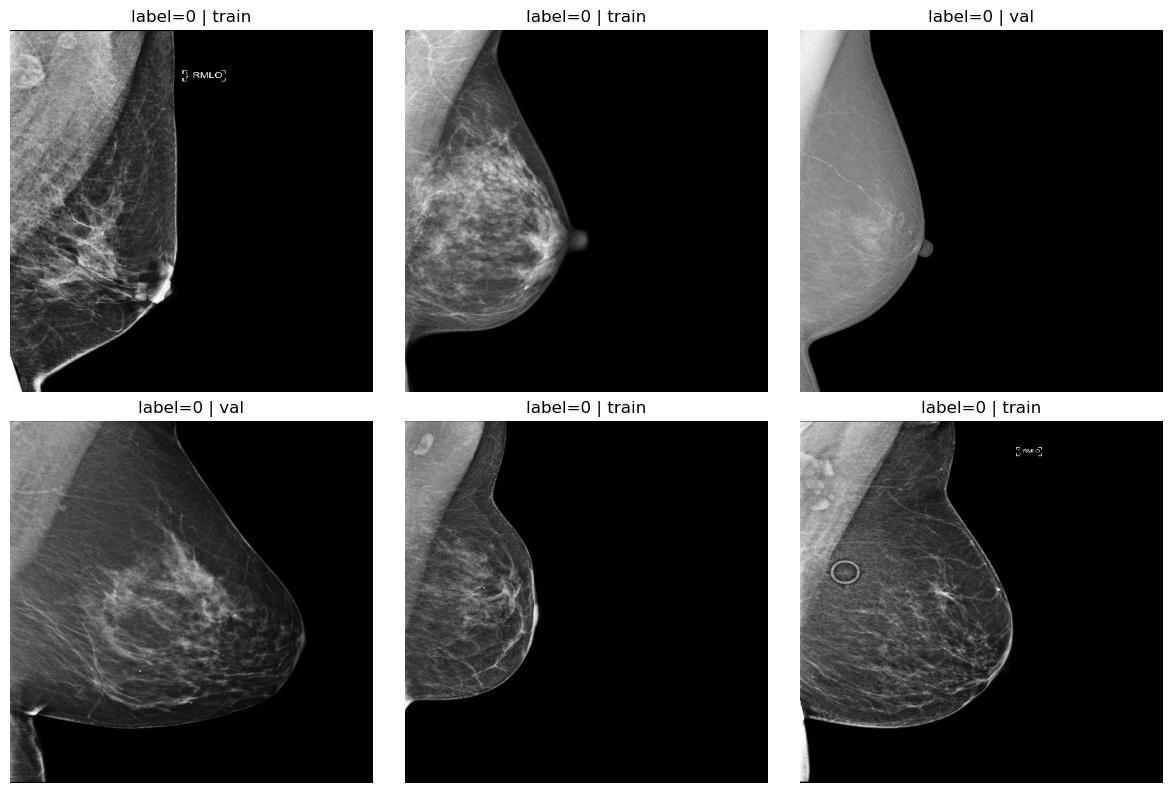

In [53]:
# Controllo metadati: stampa path, mode, size, label, split per un campione
sample = processed_df.sample(min(10, len(processed_df)), random_state=RANDOM_STATE)

for _, row in sample.iterrows():
    img = Image.open(row["processed_path"])
    print(
        row["processed_path"],
        "| mode:", img.mode,
        "| size:", img.size,
        "| label:", row["label"],
        "| split:", row["split"]
    )

# Visualizza alcune immagini preprocessate
sample_vis = processed_df.sample(min(6, len(processed_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_vis.iterrows(), start=1):
    img = Image.open(row["processed_path"])
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f'label={row["label"]} | {row["split"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()
